In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



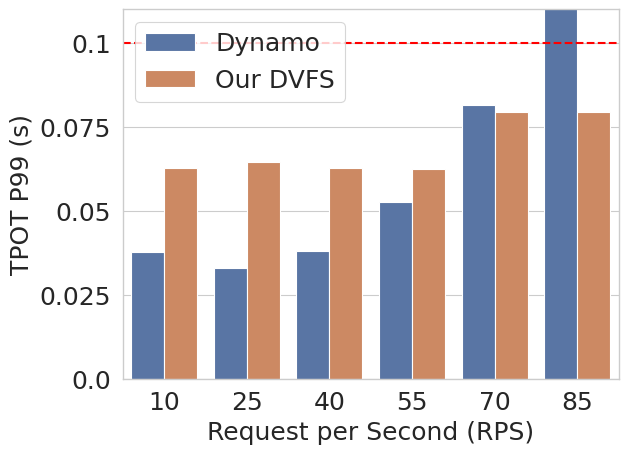

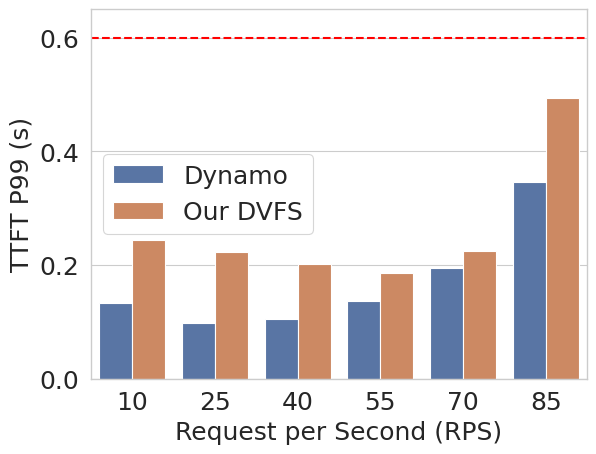

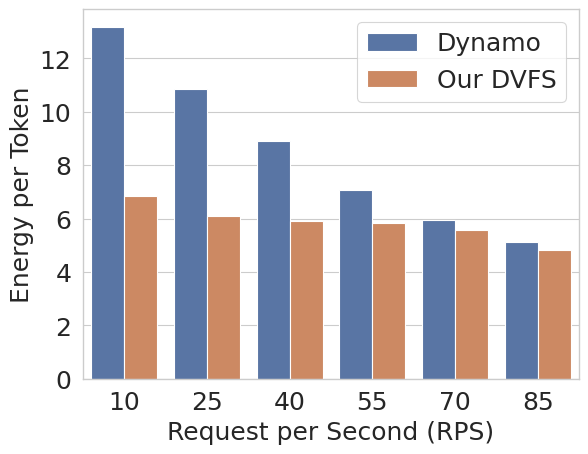

In [14]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/dynamo/profiler_logs_Feb4_dynamo_MS_azure_0/metrics.csv"
df_results_dynamo = pd.read_csv(path)

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/DVFS/dynamo_ms/profiler_logs_Feb28_chunk_dvfs_other_0/metrics.csv'
df_results_dvfs = pd.read_csv(path)

df_results = pd.concat([df_results_dynamo, df_results_dvfs])

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DYNAMO_FEB4_AZURE_SHAREGPT_MS_1_DVFS': 'Dynamo 10',
    'DYNAMO_FEB4_AZURE_SHAREGPT_MS_2_DVFS': 'Dynamo 25',
    'DYNAMO_FEB4_AZURE_SHAREGPT_MS_3_DVFS': 'Dynamo 40',
    'DYNAMO_FEB4_AZURE_SHAREGPT_MS_4_DVFS': 'Dynamo 55',
    'DYNAMO_FEB4_AZURE_SHAREGPT_MS_5_DVFS': 'Dynamo 70',
    'DYNAMO_FEB4_AZURE_SHAREGPT_MS_6_DVFS': 'Dynamo 85',
    'OURS_CHUNK_FEB24_DYNAMO_AZURE_SHAREGPT_MS_1_TP4_DVFS_node1': 'Our DVFS 85',
    'OURS_CHUNK_FEB24_DYNAMO_AZURE_SHAREGPT_MS_2_DVFS_node1': 'Our DVFS 70',
    'OURS_CHUNK_FEB24_DYNAMO_AZURE_SHAREGPT_MS_3_DVFS_node1': 'Our DVFS 55',
    'OURS_CHUNK_FEB24_DYNAMO_AZURE_SHAREGPT_MS_4_DVFS_node1': 'Our DVFS 40',
    'OURS_CHUNK_FEB24_DYNAMO_AZURE_SHAREGPT_MS_5_DVFS_node1': 'Our DVFS 25',
    'OURS_CHUNK_FEB24_DYNAMO_AZURE_SHAREGPT_MS_6_DVFS_node1': 'Our DVFS 10',
}

# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)

# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Dynamo', 'Our DVFS'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

#################### TPOT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=18)
ax.set_ylabel('TPOT P99 (s)', fontsize=18)
ax.set_ylim(0, 0.11)
ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.set_xlim([0.5, 6.5])
ax.set_xticklabels(['10', '25', '40', '55', '70', '85'], fontsize=18)
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=18)
ax.legend_.set_title('')
ax.legend(fontsize=18)
plt.savefig("figs/dynamo_MS_trace_tpot.pdf", format="pdf")

#################### TTFT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=18)
ax.set_ylabel('TTFT P99 (s)', fontsize=18)
ax.set_ylim(0, 0.65)
ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.set_xlim([0.5, 6.5])
ax.set_xticklabels(['10', '25', '40', '55', '70', '85'], fontsize=18)
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=18)
ax.legend_.set_title('')
ax.legend(fontsize=18)
plt.savefig("figs/dynamo_MS_trace_ttft.pdf", format="pdf")

#################### Energy per token ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True
)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=18)
ax.set_ylabel('Energy per Token', fontsize=18)
ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.set_xlim([0.5, 6.5])
ax.set_xticklabels(['10', '25', '40', '55', '70', '85'], fontsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.legend_.set_title('')
ax.legend(fontsize=18)
plt.savefig("figs/dynamo_MS_trace_energy_per_token.pdf", format="pdf")